In [5]:
# quiero ver la correlacion entre las variables con año del vehiculo.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2
# Cargar el dataset
df_raw = pd.read_csv("./data/raw/pf_suvs_i302_1s2025.csv")


In [6]:
#print cantidad de nans por columna
print(df_raw.isna().sum())

Unnamed: 0                     0
Marca                          0
Modelo                         0
Año                            0
Versión                        0
Color                        389
Tipo de combustible            0
Puertas                        0
Transmisión                   15
Motor                         38
Tipo de carrocería             0
Con cámara de retroceso    13563
Kilómetros                     0
Título                         0
Precio                         0
Moneda                         0
Descripción                    0
Tipo de vendedor               0
dtype: int64


bien, ahora tengo que pasar de esos valores feos a cosas para poder procesar

limpio el df

In [7]:
from preprocessing.data_cleanse import limpiar_dataset
df = limpiar_dataset(df_raw)

[TOTAL] Muestras eliminadas en total: 0


Handle missing values

In [4]:
from preprocessing.hmv import hmv_dataset

df = hmv_dataset(df, df, precio=True)


✔️ Marcas imputadas: 0
🗑️ Muestras eliminadas por no poder imputar: 0

✔️ Modelos imputados: 1
🗑️ Muestras eliminadas por no poder imputar: 0

✔️ Muestras version train imputadas: 0
🗑️ Muestras eliminadas por no poder imputar: 0
   ➤ Versiones imputadas: 0
   ➤ Muestras eliminadas por no poder imputar: 0

🗑️ Paso 2 terminado: Eliminadas 213 filas con versiones inválidas no corregibles.
[hmv_version] Muestras eliminadas: 213

✔️ Imputaciones Combustible realizadas: 0
🗑️ Muestras eliminadas: 0 

✔️ Imputaciones de puertas realizadas: 405
🗑️ Muestras eliminadas: 2
[hmv_puertas] Muestras eliminadas: 2

✔️ Imputaciones de transmision realizadas: 4102
🗑️ Muestras eliminadas: 484
[hmv_transmision] Muestras eliminadas: 484

✔️ Imputaciones de motor realizadas: 69
🗑️ Muestras eliminadas: 0

✔️ Imputaciones de camara realizadas por coincidencia exacta: 10149
🔧 Muestras sin coincidencias (asignadas 0): 2881

✔️ Imputaciones HP realizadas: 12479
🗑️ Muestras eliminadas: 46 
[hmv_hp] Muestras elimi

/Users/kekozim/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(



📊 Estadísticas finales KM:
🔍 Total de valores marcados como outliers: 1183
🛠️ Total de valores imputados exitosamente: 1183
🚫 Total de valores que quedaron como NaN: 0
✅ Imputaciones  vendedor completadas: 0 valores reemplazados.


✅ Total de colores imputados por contexto: 389

🔍 Paso 3: Agrupando colores por tokens similares...

📦 Grupos de colores formados: 32
🔗 Token base: 'blanco' → ['BLACK MEET KETTLE', 'BLANCA', 'BLANCO BANCHISA BICOLOR NEGRO', 'BLANCO BANQUISE', 'BLANCO GLACIAR', 'BLANCO NACRE TRICAPA', 'Blanca', 'Blanco', 'Blanco Glaciar', 'blanca']
🔗 Token base: 'negro' → ['NEGRA', 'Negra', 'Negro']
🔗 Token base: 'rojo' → ['ROJO SUNSET METALIZADO', 'Rojo']
🔗 Token base: 'gris' → ['GRIS ARTENSE', 'GRIS ESTRELLA', 'GRIS INDY', 'GRIS LAQUE', 'GRIS PLATA', 'GRIS PLATINO', 'GRIS SELENIUM', 'GRIS SILVERSTONE', 'GRIS TITANE', 'Gris', 'Gris oscuro', 'Gris plata']
🔗 Token base: 'plateado' → ['PLATA', 'PLATA BARI', 'PRATA BARI+TET VULC', 'Plata', 'Plateado']
🔗 Token base: 'azul' → ['A

In [5]:
from preprocessing.df_to_numeric import df_to_numeric
from preprocessing.hmv import hmv_motor
df = df_to_numeric(df, df)

#print nans and types
print(df.isna().sum())



df['Motor'].unique()

df_to_input - No quedan columnas no numéricas.
Marca                  0
Modelo                 0
Año                    0
Versión                0
Color                  0
Tipo de combustible    0
Motor                  0
tiene_camara           0
Kilómetros             0
Precio                 0
Tipo de vendedor       0
HP                     0
is_4x4                 0
is_manual              0
is_coupe               0
dtype: int64


array([1.5, 2. , 1.4, 2.4, 3.6, 1.8, 1. , 1.3, 1.2, 1.6, 2.2, 2.5, 3. ,
       2.8, 4.4, 6.4, 5.2, 4.7, 3.7, 3.2, 3.8, 4.5, 2.7, 4. , 4.2, 3.5,
       3.3, 6.1, 4.8, 5.7, 3.1, 1.9, 2.3, 4.3])

In [6]:
print(df.sample(5))

       Marca  Modelo     Año  Versión  Color  Tipo de combustible  Motor  \
12456     17      71  2016.0      190     16                    3    1.8   
10309     14      46  2019.0      150     16                    3    1.6   
15105     17      71  2020.0      188     21                    3    1.8   
17184     28      26  2021.0      307      4                    3    1.6   
3408      13      22  2017.0      134     16                    3    2.4   

       tiene_camara  Kilómetros   Precio  Tipo de vendedor     HP  is_4x4  \
12456             0    134000.0  15500.0                 0  130.0       0   
10309             1     79000.0  28800.0                 2  110.0       1   
15105             1     65000.0  23900.0                 0  130.0       0   
17184             0     58000.0  18500.0                 0  110.0       0   
3408              1    126000.0  24500.0                 1  175.0       0   

       is_manual  is_coupe  
12456          1         0  
10309          0      

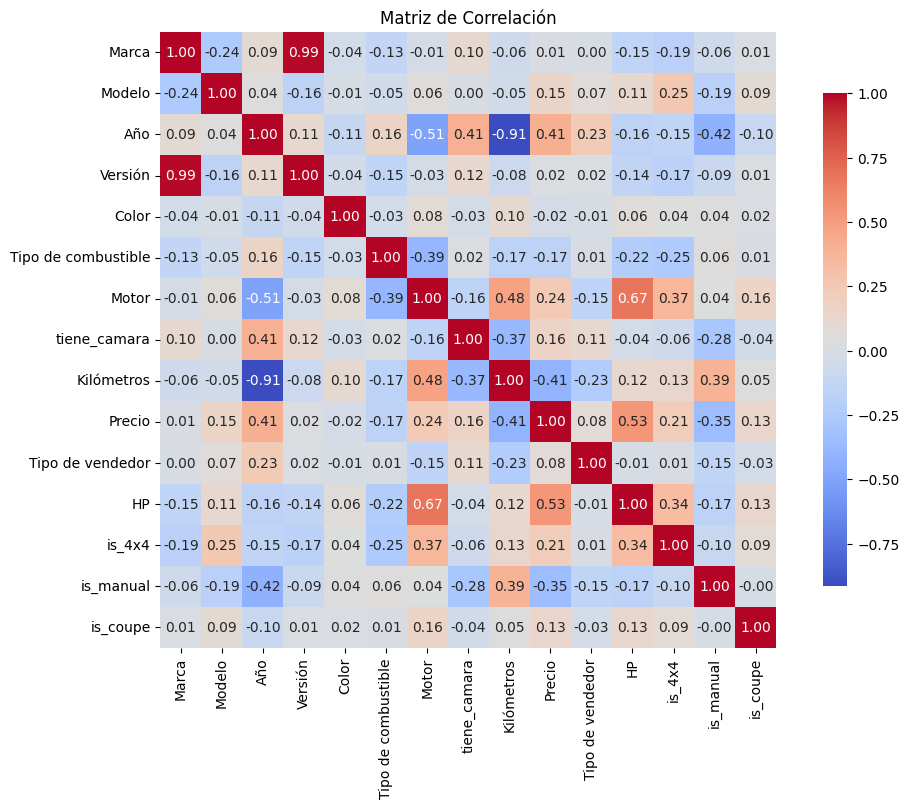

In [7]:
# train test split
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=42)
# Correlación entre las variables

# Visualizar la matriz de correlación en relacion al precio del vehiculo
plt.figure(figsize=(12, 8))
correlation_matrix = df_train.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación')
plt.show()  

In [8]:
# regression lineal simple
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# target == precio
X_train = df_train.copy().drop(columns=['Precio'])
y_train = df_train['Precio']
X_val = df_val.copy().drop(columns=['Precio'])
y_val = df_val['Precio']

# Entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)
# Predecir en el conjunto de validación
y_pred = model.predict(X_val)
# Evaluar el modelo
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
print(f'Root Mean Squared Error: {mse ** 0.5}')
print(f'R^2 Score: {r2}')




Root Mean Squared Error: 11070.574712633592
R^2 Score: 0.5937258640208591


In [9]:
# XGboost
from xgboost import XGBRegressor
# Entrenar el modelo de XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
# Predecir en el conjunto de validación
y_pred_xgb = xgb_model.predict(X_val)
# Evaluar el modelo
mse_xgb = mean_squared_error(y_val, y_pred_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)
print(f'XGBoost Root Mean Squared Error: {mse_xgb ** 0.5}')
print(f'XGBoost R^2 Score: {r2_xgb}')

#test the model on the test set
y_test_pred = xgb_model.predict(df_test.drop(columns=['Precio']))
test_mse = mean_squared_error(df_test['Precio'], y_test_pred)
test_r2 = r2_score(df_test['Precio'], y_test_pred)
print(f'Test Root Mean Squared Error: {test_mse ** 0.5}')
print(f'Test R^2 Score: {test_r2}')

XGBoost Root Mean Squared Error: 4816.081936120438
XGBoost R^2 Score: 0.9231105817761667
Test Root Mean Squared Error: 5851.675592310111
Test R^2 Score: 0.9039659775788245


In [13]:
# prueba solamente hmv_precio en train
from preprocessing.hmv import hmv_precio
df_train_hmv_precio = hmv_precio(df_train, df_train)

xgb_model_hmv_precio = XGBRegressor(n_estimators=100, random_state=42)
xgb_model_hmv_precio.fit(df_train_hmv_precio.drop(columns=['Precio']), df_train_hmv_precio['Precio'])
# Predecir en el conjunto de validación

y_pred_hmv_precio = xgb_model_hmv_precio.predict(df_val.drop(columns=['Precio']))
# Evaluar el modelo
mse_hmv_precio = mean_squared_error(df_val['Precio'], y_pred_hmv_precio)
r2_hmv_precio = r2_score(df_val['Precio'], y_pred_hmv_precio)
print(f'HMV Precio Root Mean Squared Error: {mse_hmv_precio ** 0.5}')
print(f'HMV Precio R^2 Score: {r2_hmv_precio}')
#test the model on the test set
y_test_pred_hmv_precio = xgb_model_hmv_precio.predict(df_test.drop(columns=['Precio']))
test_mse_hmv_precio = mean_squared_error(df_test['Precio'], y_test_pred_hmv_precio)
test_r2_hmv_precio = r2_score(df_test['Precio'], y_test_pred_hmv_precio)
print(f'Test HMV Precio Root Mean Squared Error: {test_mse_hmv_precio ** 0.5}')
print(f'Test HMV Precio R^2 Score: {test_r2_hmv_precio}')


📊 Estadísticas finales precio:
🔧 Valores modificados por ser outliers: 303
🪛 Valores imputados por fallback (Marca+Modelo+Versión+Año): 0
🧮 Valores imputados con media general del dataset: 0
❓ Valores que siguen como NaN: 0 / 11205
HMV Precio Root Mean Squared Error: 4735.041188153258
HMV Precio R^2 Score: 0.925676464042733
Test HMV Precio Root Mean Squared Error: 5681.4049057705215
Test HMV Precio R^2 Score: 0.9094734185013129


In [14]:
final_test = pd.read_csv("./data/raw/SUVS_2025-test-masked.csv")

In [16]:
#  quiero chequiar que marca sube mas el precio
df_train['Marca'].unique()
df_train.groupby('Marca')['Precio'].mean().sort_values(ascending=False)


Marca
27    90274.372093
0     81620.000000
1     57659.177258
33    51574.545455
3     48404.727612
23    47077.569444
9     45690.909091
21    40682.689655
31    37326.716456
12    34745.714286
2     33543.516667
18    33192.500000
17    31961.670257
24    29643.750000
32    28373.276295
19    26800.000000
14    23224.754545
25    23109.082504
20    22226.635870
5     21894.248175
13    21441.902632
10    21422.350877
26    20786.410323
22    19793.333333
6     19306.943878
11    17504.478026
16    16804.615385
28    15745.734841
8     14903.834862
30    14614.693878
4     13481.848214
15    11200.000000
29     8967.272727
7      8200.000000
Name: Precio, dtype: float64